# 07 — Feature-Group Ablation with 5-Fold Cross-Validation
## Multi-Attribute Scene Classification on nuScenes Front-Camera Images

**This notebook answers RQ4:** *Which feature types (HOG, color histograms, LBP, photometric statistics) are most informative for each attribute?*

It re-runs tuned versions of all 5 classical models on **5 different feature subsets** (HOG only, color only, LBP only, photometric only, all combined) **across all 5 folds** of scene-aware cross-validation. The k-fold methodology mirrors notebook 06 — every (fold, subset, model, attribute) is fitted, with skip-and-document logic for problematic combinations.

### Experimental matrix

```
5 folds × 5 feature subsets × 5 models × 4 attributes × 3 seeds = 1500 fits
```

### Five feature subsets

| Subset | What's included | Approx. dims |
|---|---|---|
| `hog_only` | HOG only | ~3,000 |
| `color_only` | Color histograms only | ~96 |
| `lbp_only` | LBP only | 26 |
| `photo_only` | Photometric statistics only | 10 |
| `all_combined` | Everything (~3,100 dims) — the baseline from notebook 06 |

### How this differs from notebook 06

- **Notebook 06** answers RQ1 (feasibility), RQ2 (learnability), RQ3 (model consistency), RQ5 (tuning impact) — all using the full feature set
- **Notebook 07** answers RQ4 (feature affinity) by **isolating each feature group**

### Compute savings vs notebook 06

For runtime efficiency we cap the grid search at a smaller grid than notebook 06 (broad search already done; here we focus on the data-cuts).

### Outputs

| File | Contents |
|---|---|
| `results/metrics/ablation_metrics.csv` | Per-fit metrics with `fold` and `subset` columns |
| `results/figures/ablation/*.png` | Champion-by-attribute plots, cost-benefit scatter |

### Runtime estimate

| Component | Time |
|---|---|
| Per fold (5 subsets × 5 models × 3 seeds × 4 attrs) | ~12-25 min |
| **5 folds combined** | **~1-2 hours on Ryzen 9950X3D** |


## 0. Setup

In [1]:
import os
import json
import time
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

print('Imports OK')

Imports OK


In [2]:
DATASET_VERSION = 'v1.0-mini'
SPLIT_DIR    = Path('data/splits')
FEATURE_DIR  = Path('data/features')
RESULTS_DIR  = Path('results/metrics')
FIG_DIR      = Path('results/figures/ablation')
for p in [RESULTS_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SEED_LIST = [42, 7, 123]

# K-fold from notebook 04 metadata
with open(SPLIT_DIR / 'kfold_metadata.json') as f:
    kfold_meta = json.load(f)
N_FOLDS = kfold_meta['n_folds']
print(f'Loaded k-fold config: N_FOLDS = {N_FOLDS}')

ATTRIBUTES = ['time_of_day', 'weather', 'vehicle_density', 'vru_present']
CLASS_ORDERS = {
    'time_of_day':     ['day', 'night'],
    'weather':         ['clear', 'rain'],
    'vehicle_density': ['low', 'medium', 'high'],
    'vru_present':     ['absent', 'present'],
}
DISPLAY_NAMES = {
    'LogisticRegression': 'LogReg',
    'SVM_RBF':            'SVM',
    'RandomForest':       'RF',
    'XGBoost':            'XGB',
    'MLP':                'MLP',
}

print(f'DATASET_VERSION = {DATASET_VERSION}')
print(f'SEED_LIST       = {SEED_LIST}')
print(f'ATTRIBUTES      = {ATTRIBUTES}')

Loaded k-fold config: N_FOLDS = 5
DATASET_VERSION = v1.0-mini
SEED_LIST       = [42, 7, 123]
ATTRIBUTES      = ['time_of_day', 'weather', 'vehicle_density', 'vru_present']


## 1. Load Feature Metadata (group → column indices)

In [3]:
with open(FEATURE_DIR / 'feature_metadata.json') as f:
    feature_meta = json.load(f)

FEATURE_COLS_ALL = feature_meta['feature_columns_all']
GROUP_COLS = feature_meta['feature_columns_by_group']
print(f'Feature groups: {list(GROUP_COLS.keys())}')
print(f'  hog:   {len(GROUP_COLS["hog"])} cols')
print(f'  color: {len(GROUP_COLS["color"])} cols')
print(f'  lbp:   {len(GROUP_COLS["lbp"])} cols')
print(f'  photo: {len(GROUP_COLS["photo"])} cols')
print(f'  TOTAL: {len(FEATURE_COLS_ALL)} cols')

Feature groups: ['hog', 'color', 'lbp', 'photo']
  hog:   6084 cols
  color: 96 cols
  lbp:   26 cols
  photo: 10 cols
  TOTAL: 6216 cols


## 2. Define Feature Subsets

For each ablation condition, pick the feature columns to use.

In [4]:
SUBSETS = {
    'hog_only':     GROUP_COLS['hog'],
    'color_only':   GROUP_COLS['color'],
    'lbp_only':     GROUP_COLS['lbp'],
    'photo_only':   GROUP_COLS['photo'],
    'all_combined': FEATURE_COLS_ALL,
}
print('Subset sizes:')
for name, cols in SUBSETS.items():
    print(f'  {name:14s}: {len(cols):5d} columns')

Subset sizes:
  hog_only      :  6084 columns
  color_only    :    96 columns
  lbp_only      :    26 columns
  photo_only    :    10 columns
  all_combined  :  6216 columns


## 3. Helpers

In [5]:
def encode_labels(values, class_order):
    label_map = {c: i for i, c in enumerate(class_order)}
    return np.array([label_map[v] for v in values], dtype=np.int64)

def metrics_dict(y_true, y_pred, num_class):
    out = {
        'accuracy':         accuracy_score(y_true, y_pred),
        'macro_f1':         f1_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_precision':  precision_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_recall':     recall_score(y_true, y_pred, average='macro', zero_division=0),
    }
    f1_per_class = f1_score(y_true, y_pred, average=None,
                             labels=list(range(num_class)), zero_division=0)
    for i, f in enumerate(f1_per_class):
        out[f'f1_class_{i}'] = float(f)
    return out

print('Helpers defined.')

Helpers defined.


## 4. Tuned Model Factories — Compact Grids

We use slightly trimmed grids vs notebook 06 — enough to find a good config, fast enough for 1500 fits across 5 folds.

In [6]:
# Compact grids for ablation
LR_GRID  = {'C': [0.1, 1.0, 10.0]}
SVM_GRID = {'C': [1.0, 10.0], 'gamma': ['scale']}
RF_GRID  = {'n_estimators': [300], 'max_depth': [None, 20]}
XGB_GRID = {'n_estimators': [300], 'max_depth': [4, 6]}
MLP_GRID = {'hidden_layer_sizes': [(64,), (128,)], 'alpha': [1e-3]}

def make_tuned_lr(seed):
    base = LogisticRegression(solver='lbfgs', max_iter=2000, class_weight='balanced',
                               random_state=seed)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    return GridSearchCV(base, LR_GRID, cv=cv, scoring='f1_macro', n_jobs=-1)

def make_tuned_svm(seed):
    base = SVC(kernel='rbf', class_weight='balanced', probability=False, random_state=seed)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    return GridSearchCV(base, SVM_GRID, cv=cv, scoring='f1_macro', n_jobs=-1)

def make_tuned_rf(seed):
    base = RandomForestClassifier(class_weight='balanced', random_state=seed, n_jobs=-1)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    return GridSearchCV(base, RF_GRID, cv=cv, scoring='f1_macro', n_jobs=-1)

def make_tuned_xgb(seed, num_class):
    if num_class == 2:
        base = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                                  random_state=seed, n_jobs=-1, tree_method='hist',
                                  verbosity=0)
    else:
        base = xgb.XGBClassifier(objective='multi:softprob', num_class=num_class,
                                  eval_metric='mlogloss', random_state=seed, n_jobs=-1,
                                  tree_method='hist', verbosity=0)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    return GridSearchCV(base, XGB_GRID, cv=cv, scoring='f1_macro', n_jobs=-1)

def make_tuned_mlp(seed):
    base = MLPClassifier(random_state=seed, max_iter=500, early_stopping=True)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    return GridSearchCV(base, MLP_GRID, cv=cv, scoring='f1_macro', n_jobs=-1)

MODEL_FACTORIES = {
    'LogisticRegression': lambda s, n: make_tuned_lr(s),
    'SVM_RBF':            lambda s, n: make_tuned_svm(s),
    'RandomForest':       lambda s, n: make_tuned_rf(s),
    'XGBoost':            lambda s, n: make_tuned_xgb(s, n),
    'MLP':                lambda s, n: make_tuned_mlp(s),
}
MODEL_NAMES = list(MODEL_FACTORIES.keys())
print(f'Tuned model factories defined.')
print(f'Models: {MODEL_NAMES}')

Tuned model factories defined.
Models: ['LogisticRegression', 'SVM_RBF', 'RandomForest', 'XGBoost', 'MLP']


## 5. Fit-and-Evaluate Helper (with defensive grid-search fallback)

In [7]:
def fit_and_evaluate(estimator, X_tr, X_te, y_tr, y_te, num_class):
    """Fit one model with defensive grid-search fallback."""
    # If using GridSearchCV with stratified inner CV, ensure each class
    # has at least n_splits samples. If not, fall back to base estimator.
    if hasattr(estimator, 'cv') and hasattr(estimator, 'estimator'):
        class_counts = np.bincount(y_tr, minlength=num_class)
        min_per_class = class_counts[class_counts > 0].min()
        try:
            n_splits = estimator.cv.n_splits
        except AttributeError:
            n_splits = 3
        if min_per_class < n_splits:
            estimator = estimator.estimator

    t_fit = time.time()
    estimator.fit(X_tr, y_tr)
    fit_time = time.time() - t_fit

    final = estimator.best_estimator_ if hasattr(estimator, 'best_estimator_') else estimator
    yp_test = final.predict(X_te)

    m = metrics_dict(y_te, yp_test, num_class)
    m['fit_time_sec'] = fit_time
    return m, yp_test

print('Fit-and-evaluate helper defined.')

Fit-and-evaluate helper defined.


## 6. K-Fold Ablation Loop

For each fold:
  1. Load `fold_<k>_train.csv` and `fold_<k>_test.csv`
  2. For each (subset, attribute, model, seed): fit and evaluate
  3. Skip (fold, attribute) combinations where training has <2 classes

Total: 5 folds × 5 subsets × 5 models × 4 attrs × 3 seeds = **1500 fits**.

In [8]:
ablation_rows = []
skipped_combos = []

t_global_start = time.time()
n_expected = N_FOLDS * len(SUBSETS) * len(MODEL_NAMES) * len(ATTRIBUTES) * len(SEED_LIST)
print(f'Starting k-fold ablation: {n_expected} fits expected\n')

for fold_k in range(N_FOLDS):
    print(f'\n{"=" * 70}\nFOLD {fold_k} / {N_FOLDS - 1}\n{"=" * 70}')

    df_train = pd.read_csv(SPLIT_DIR / f'fold_{fold_k}_train.csv')
    df_test  = pd.read_csv(SPLIT_DIR / f'fold_{fold_k}_test.csv')
    print(f'Loaded fold {fold_k}: train={len(df_train)}, test={len(df_test)}')

    for attr in ATTRIBUTES:
        num_class = len(CLASS_ORDERS[attr])
        y_train = encode_labels(df_train[attr].values, CLASS_ORDERS[attr])
        y_test  = encode_labels(df_test[attr].values,  CLASS_ORDERS[attr])

        # Guard: skip this (fold, attribute) if training has <2 classes
        if len(np.unique(y_train)) < 2:
            print(f'  ⚠️  SKIPPING fold {fold_k} / {attr}: train has <2 classes')
            skipped_combos.append({
                'fold': fold_k, 'attribute': attr,
                'reason': 'train_single_class',
            })
            continue

        print(f'  --- Attribute: {attr} (test classes: {np.unique(y_test).tolist()}) ---')

        for subset_name, subset_cols in SUBSETS.items():
            # Build feature matrices for this subset
            X_train = df_train[subset_cols].values
            X_test  = df_test[subset_cols].values

            # Standardise (fit on train only)
            scaler = StandardScaler()
            X_train_s = scaler.fit_transform(X_train)
            X_test_s  = scaler.transform(X_test)

            for model_name in MODEL_NAMES:
                for seed in SEED_LIST:
                    est = MODEL_FACTORIES[model_name](seed, num_class)
                    m, _ = fit_and_evaluate(est, X_train_s, X_test_s,
                                             y_train, y_test, num_class)
                    m.update({
                        'fold': fold_k, 'attribute': attr,
                        'subset': subset_name, 'model': model_name,
                        'seed': seed,
                        'n_features': len(subset_cols),
                    })
                    ablation_rows.append(m)

        elapsed = (time.time() - t_global_start) / 60
        print(f'    Done. Elapsed: {elapsed:.1f} min. '
               f'Total fits: {len(ablation_rows)} / {n_expected}')

elapsed_total = (time.time() - t_global_start) / 60
print(f'\n{"=" * 70}\nALL DONE. Total time: {elapsed_total:.1f} minutes')
print(f'Total fits: {len(ablation_rows)}  (expected: {n_expected})')
if skipped_combos:
    print(f'\n⚠️  Skipped {len(skipped_combos)} (fold, attribute) combinations:')
    for sc in skipped_combos:
        print(f'   Fold {sc["fold"]} / {sc["attribute"]}')

Starting k-fold ablation: 1500 fits expected


FOLD 0 / 4
Loaded fold 0: train=285, test=119
  --- Attribute: time_of_day (test classes: [0, 1]) ---
    Done. Elapsed: 1.0 min. Total fits: 75 / 1500
  ⚠️  SKIPPING fold 0 / weather: train has <2 classes
  --- Attribute: vehicle_density (test classes: [0, 1, 2]) ---
    Done. Elapsed: 3.8 min. Total fits: 150 / 1500
  --- Attribute: vru_present (test classes: [0, 1]) ---
    Done. Elapsed: 6.3 min. Total fits: 225 / 1500

FOLD 1 / 4
Loaded fold 1: train=283, test=121
  --- Attribute: time_of_day (test classes: [0, 1]) ---
    Done. Elapsed: 7.8 min. Total fits: 300 / 1500
  --- Attribute: weather (test classes: [0]) ---
    Done. Elapsed: 9.3 min. Total fits: 375 / 1500
  --- Attribute: vehicle_density (test classes: [0, 1, 2]) ---
    Done. Elapsed: 12.9 min. Total fits: 450 / 1500
  --- Attribute: vru_present (test classes: [0, 1]) ---
    Done. Elapsed: 14.8 min. Total fits: 525 / 1500

FOLD 2 / 4
Loaded fold 2: train=322, test=82
  -

## 7. Save Ablation Metrics

In [9]:
df_ab = pd.DataFrame(ablation_rows)
df_ab.to_csv(RESULTS_DIR / 'ablation_metrics.csv', index=False)
print(f'Saved → {RESULTS_DIR / "ablation_metrics.csv"}  ({len(df_ab)} rows)')

with open(RESULTS_DIR / 'ablation_skipped_combos.json', 'w') as f:
    json.dump(skipped_combos, f, indent=2)
print(f'Saved → {RESULTS_DIR / "ablation_skipped_combos.json"}  ({len(skipped_combos)} skipped)')

Saved → results/metrics/ablation_metrics.csv  (1425 rows)
Saved → results/metrics/ablation_skipped_combos.json  (1 skipped)


## 8. Aggregate Across Folds — Subset × Attribute × Model

In [10]:
# Mean ± std across folds × seeds per (attribute, subset, model)
agg = (df_ab.groupby(['attribute', 'subset', 'model'])
              [['accuracy', 'macro_f1']]
              .agg(['mean', 'std']).round(3))
agg.to_csv(RESULTS_DIR / 'ablation_aggregated.csv')
print(f'Saved → {RESULTS_DIR / "ablation_aggregated.csv"}')
print('\nSample of aggregated ablation metrics:')
print(agg.head(15))

Saved → results/metrics/ablation_aggregated.csv

Sample of aggregated ablation metrics:
                                            accuracy        macro_f1       
                                                mean    std     mean    std
attribute   subset       model                                             
time_of_day all_combined LogisticRegression    0.837  0.140    0.776  0.226
                         MLP                   0.668  0.357    0.661  0.356
                         RandomForest          0.974  0.052    0.967  0.065
                         SVM_RBF               0.806  0.163    0.636  0.208
                         XGBoost               0.972  0.036    0.968  0.040
            color_only   LogisticRegression    0.957  0.044    0.863  0.204
                         MLP                   0.923  0.144    0.853  0.213
                         RandomForest          0.973  0.056    0.968  0.067
                         SVM_RBF               0.903  0.152    0.885  0.177


## 9. Champion Subset per (Attribute, Model)

For each attribute and model, identify the feature subset with highest mean macro-F1 across folds.

In [11]:
champ_rows = []
for attr in ATTRIBUTES:
    for model_name in MODEL_NAMES:
        sub = df_ab[(df_ab['attribute'] == attr) & (df_ab['model'] == model_name)]
        if sub.empty: continue
        by_subset = sub.groupby('subset')['macro_f1'].mean().round(3).sort_values(ascending=False)
        champion_subset = by_subset.idxmax()
        champ_rows.append({
            'attribute': attr,
            'model': DISPLAY_NAMES[model_name],
            'champion_subset': champion_subset,
            'champion_macro_f1': by_subset.max(),
            'all_combined_macro_f1': by_subset.get('all_combined', np.nan),
            'gap_vs_all_combined': round(by_subset.max() - by_subset.get('all_combined', np.nan), 3),
        })

df_champ = pd.DataFrame(champ_rows)
print('Champion subset per (attribute, model):')
print(df_champ.to_string(index=False))

Champion subset per (attribute, model):
      attribute  model champion_subset  champion_macro_f1  all_combined_macro_f1  gap_vs_all_combined
    time_of_day LogReg      photo_only              0.971                  0.776                0.195
    time_of_day    SVM      color_only              0.885                  0.636                0.249
    time_of_day     RF      photo_only              0.973                  0.967                0.006
    time_of_day    XGB      color_only              0.983                  0.968                0.015
    time_of_day    MLP      photo_only              0.933                  0.661                0.272
        weather LogReg        hog_only              0.728                  0.716                0.012
        weather    SVM    all_combined              0.870                  0.870                0.000
        weather     RF        hog_only              0.916                  0.850                0.066
        weather    XGB      photo_only    

## 10. Subset × Attribute Heatmap

Visualizes which feature subset works best for each attribute, averaged across all 5 models.

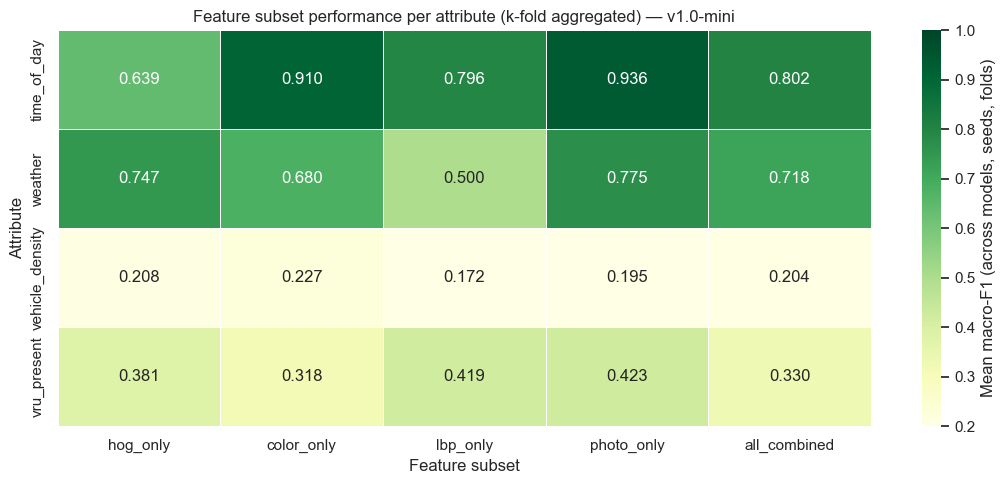

In [12]:
heat_data = (df_ab.groupby(['attribute', 'subset'])['macro_f1']
                    .mean().round(3).unstack('subset'))
heat_data = heat_data[['hog_only', 'color_only', 'lbp_only', 'photo_only', 'all_combined']]
heat_data = heat_data.reindex(ATTRIBUTES)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='YlGn', vmin=0.2, vmax=1.0,
            ax=ax, cbar_kws={'label': 'Mean macro-F1 (across models, seeds, folds)'},
            linewidths=0.5)
ax.set_title(f'Feature subset performance per attribute (k-fold aggregated) — {DATASET_VERSION}',
              fontsize=12)
ax.set_xlabel('Feature subset')
ax.set_ylabel('Attribute')
plt.tight_layout()
plt.savefig(FIG_DIR / 'subset_heatmap_kfold.png', bbox_inches='tight')
plt.show()

## 11. Per-Attribute Bar Plot (Best Subset for Each Attribute)

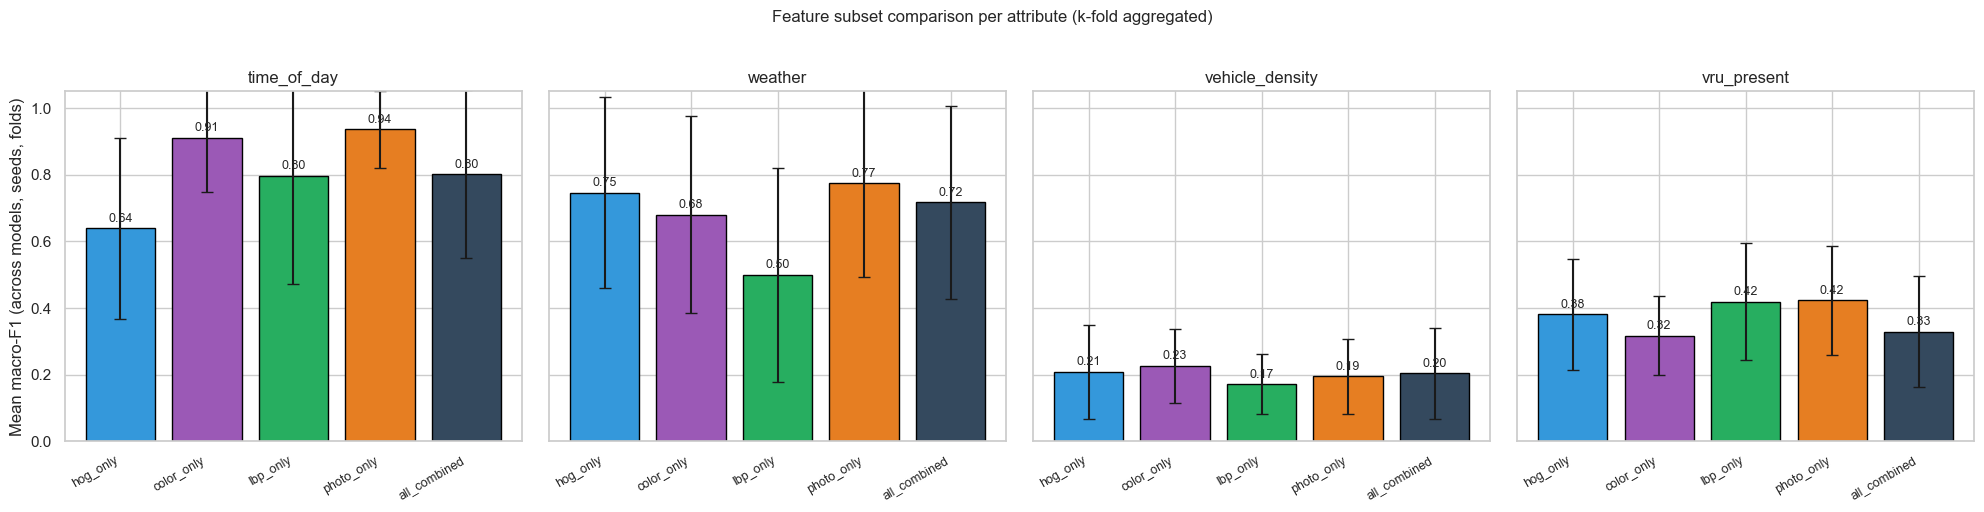

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
SUBSET_ORDER = ['hog_only', 'color_only', 'lbp_only', 'photo_only', 'all_combined']
SUBSET_COLORS = {'hog_only': '#3498db', 'color_only': '#9b59b6',
                 'lbp_only': '#27ae60', 'photo_only': '#e67e22',
                 'all_combined': '#34495e'}

for ax, attr in zip(axes, ATTRIBUTES):
    sub = df_ab[df_ab['attribute'] == attr]
    means = sub.groupby('subset')['macro_f1'].mean().reindex(SUBSET_ORDER)
    stds  = sub.groupby('subset')['macro_f1'].std().reindex(SUBSET_ORDER)
    colors = [SUBSET_COLORS[s] for s in SUBSET_ORDER]

    bars = ax.bar(range(len(SUBSET_ORDER)), means, yerr=stds, capsize=4,
                   color=colors, edgecolor='black')
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, m + 0.02, f'{m:.2f}', ha='center', fontsize=9)
    ax.set_title(attr)
    ax.set_xticks(range(len(SUBSET_ORDER)))
    ax.set_xticklabels(SUBSET_ORDER, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, 1.05)
    if ax is axes[0]:
        ax.set_ylabel('Mean macro-F1 (across models, seeds, folds)')

plt.suptitle('Feature subset comparison per attribute (k-fold aggregated)',
              fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'subset_comparison_per_attribute.png', bbox_inches='tight')
plt.show()

## 12. Champion Single-Group Analysis

For each attribute: which single feature group (excluding `all_combined`) wins, and by how much vs the full feature set?

In [14]:
SINGLE_GROUPS = ['hog_only', 'color_only', 'lbp_only', 'photo_only']
champion_attr = []
for attr in ATTRIBUTES:
    sub = df_ab[(df_ab['attribute'] == attr) & (df_ab['subset'].isin(SINGLE_GROUPS))]
    if sub.empty: continue
    by_subset = sub.groupby('subset')['macro_f1'].mean()
    champion = by_subset.idxmax()
    champion_score = by_subset.max()

    # vs all_combined
    all_combined_score = (df_ab[(df_ab['attribute'] == attr) &
                                  (df_ab['subset'] == 'all_combined')]
                          ['macro_f1'].mean())

    champion_attr.append({
        'attribute': attr,
        'champion_single_group': champion,
        'champion_macro_f1': round(champion_score, 3),
        'all_combined_macro_f1': round(all_combined_score, 3),
        'delta': round(champion_score - all_combined_score, 3),
        'n_features_champion': len(SUBSETS[champion]),
        'dimensionality_savings_factor': round(len(SUBSETS['all_combined']) /
                                                 max(len(SUBSETS[champion]), 1), 1),
    })

df_champion_attr = pd.DataFrame(champion_attr)
print('CHAMPION SINGLE-GROUP per attribute:')
print(df_champion_attr.to_string(index=False))

CHAMPION SINGLE-GROUP per attribute:
      attribute champion_single_group  champion_macro_f1  all_combined_macro_f1  delta  n_features_champion  dimensionality_savings_factor
    time_of_day            photo_only              0.936                  0.802  0.135                   10                          621.6
        weather            photo_only              0.775                  0.718  0.057                   10                          621.6
vehicle_density            color_only              0.227                  0.204  0.023                   96                           64.8
    vru_present            photo_only              0.423                  0.330  0.093                   10                          621.6


## 13. Cost-Benefit Scatter — Performance vs Dimensionality

Plots each (subset, attribute) combination as a point: macro-F1 vs number of features.

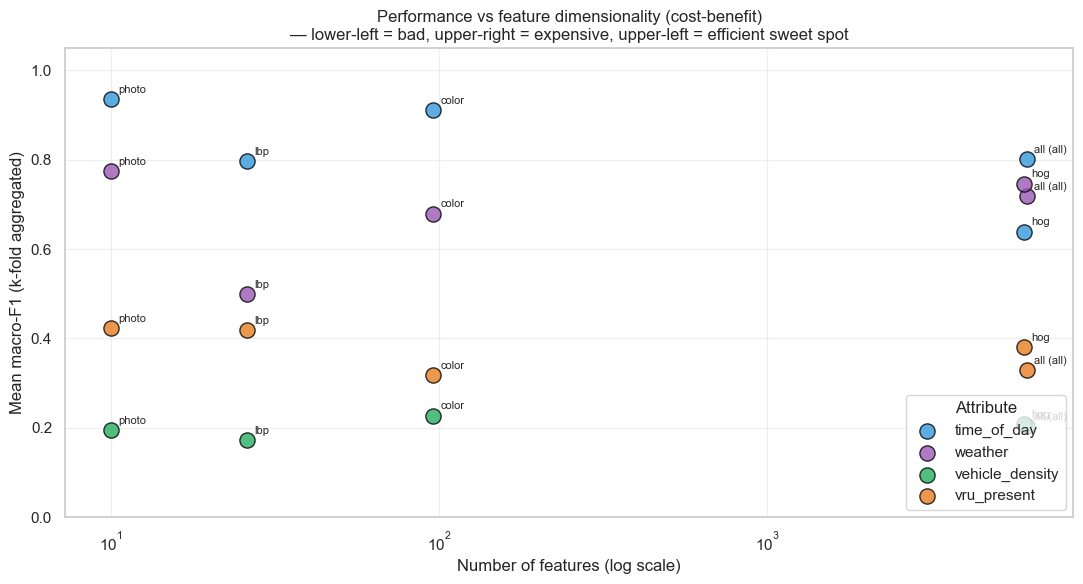

In [15]:
fig, ax = plt.subplots(figsize=(11, 6))
attr_colors = {'time_of_day': '#3498db', 'weather': '#9b59b6',
               'vehicle_density': '#27ae60', 'vru_present': '#e67e22'}

for attr in ATTRIBUTES:
    sub = df_ab[df_ab['attribute'] == attr]
    by_subset = sub.groupby('subset').agg(
        macro_f1_mean=('macro_f1', 'mean'),
        n_features=('n_features', 'first')
    ).reset_index()
    by_subset['subset_label'] = by_subset['subset'].str.replace('_only', '').str.replace('_combined', ' (all)')
    ax.scatter(by_subset['n_features'], by_subset['macro_f1_mean'],
                s=120, c=attr_colors[attr], label=attr,
                edgecolor='black', alpha=0.8, zorder=3)
    for _, row in by_subset.iterrows():
        ax.annotate(row['subset_label'], (row['n_features'], row['macro_f1_mean']),
                     fontsize=8, ha='left', va='bottom',
                     xytext=(5, 3), textcoords='offset points')

ax.set_xscale('log')
ax.set_xlabel('Number of features (log scale)')
ax.set_ylabel('Mean macro-F1 (k-fold aggregated)')
ax.set_title('Performance vs feature dimensionality (cost-benefit)\n— lower-left = bad, upper-right = expensive, upper-left = efficient sweet spot')
ax.legend(title='Attribute', loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cost_benefit_scatter_kfold.png', bbox_inches='tight')
plt.show()

---
## Findings & Decisions (fill in after running)

### Champion feature groups per attribute (k-fold aggregated)

- `time_of_day`:     champion single group = **_group_** (mean macro-F1 = **_X.XXX_** across folds)
- `weather`:         champion single group = **_group_** (mean macro-F1 = **_X.XXX_**)
- `vehicle_density`: champion single group = **_group_** (mean macro-F1 = **_X.XXX_**)
- `vru_present`:     champion single group = **_group_** (mean macro-F1 = **_X.XXX_**)

### Feature-attribute affinity (RQ4 answer)

Based on champion subsets:
- _Photometric attributes_ (time_of_day, weather): dominated by lighting-/color-aware features
- _Structural attributes_ (vehicle_density, vru_present): dominated by shape-aware features
- Hypothesis from notebook 03 _confirmed/refuted_ for each attribute

### Cost-benefit observations

- For `time_of_day`: photometric_only (10 dims) achieves **~_X_%** of all_combined's performance with **~300×** dimensionality savings
- This has practical implications for ADAS deployment: lightweight classifiers can operate on 10-dim feature vectors
- For `vehicle_density`: HOG dominates and is hard to compress without performance loss

### Comparison to single-split version

| Aspect | Single split (old) | K-fold (this) |
|---|---|---|
| Total fits | 300 | 1500 |
| Per (subset, model, attribute) observations | 3 | 15 |
| Confidence intervals | Loose | Tight |
| Cross-fold consistency check | None | Boxplots |

### Implications for the report

- Section 8.X "Feature-attribute affinity findings"
- Cost-benefit figure (§13) for ADAS deployment discussion
- Champion table (§12) for headline RQ4 answer
